# Notebook 03: Análisis Comparativo de Modelos de Segmentación

**Objetivos:**
1. Cargar y comparar modelos entrenados desde diferentes experimentos
2. Análisis estadístico detallado de rendimiento
3. Visualizaciones cualitativas y cuantitativas

**Modelos evaluados:**
- U-Net Básica: Arquitectura encoder-decoder clásica
- Attention U-Net: U-Net con mecanismos de atención en skip connections
- Residual U-Net: U-Net con conexiones residuales
- U-Net++: Arquitectura anidada con skip connections densos
- DeepLabV3+: ASPP + backbone preentrenado (ResNet)
- TransUNet: Híbrido CNN-Transformer

**Metodología:**
- Carga de modelos desde experimentos anteriores
- Evaluación en conjunto de validación y test
- Análisis estadístico (distribuciones, correlaciones, significancia)
- Visualización de segmentaciones representativas
- Comparación con referencias del estado del arte

## 1. Configuración inicial y carga de librerías

In [1]:
# Configuración inicial
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import torch
import json
import warnings
from scipy import stats
from sklearn.metrics import roc_curve, auc
import itertools
warnings.filterwarnings('ignore')

# Configuración de estilo para gráficos académicos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
plt.rcParams.update({
    'figure.figsize': (14, 8),
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'figure.titleweight': 'bold',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.transparent': False
})

# Añadir src al path
import os
PROJECT_ROOT = Path.cwd().parent if "notebooks" in str(Path.cwd()) else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

# Importaciones personalizadas
from src.data_preparation.data_loader import ISICDataLoader
from src.models import (
    UNet, AttentionUNet, ResidualUNet,
    UNetPlusPlus, DeepLabV3Plus, TransUNet
)
from src.models.metrics import SegmentationMetrics

# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

Dispositivo: cuda


## 2. Carga de modelos entrenados

In [2]:
# Mapeo de nombres de clase de modelo a clases
MODEL_CLASS_MAP = {
    'UNet': UNet,
    'AttentionUNet': AttentionUNet,
    'ResidualUNet': ResidualUNet,
    'UNetPlusPlus': UNetPlusPlus,
    'DeepLabV3Plus': DeepLabV3Plus,
    'TransUNet': TransUNet
}

def get_model_class_from_name(model_name):
    """Determina la clase de modelo basándose en el nombre del experimento"""
    name_lower = model_name.lower()
    
    # Orden de búsqueda importante: más específico primero
    if '++' in name_lower or 'plusplus' in name_lower:
        return UNetPlusPlus
    elif 'deeplab' in name_lower:
        return DeepLabV3Plus
    elif 'trans' in name_lower:
        return TransUNet
    elif 'attention' in name_lower:
        return AttentionUNet
    elif 'residual' in name_lower:
        return ResidualUNet
    else:
        return UNet

def load_trained_models(model_paths):
    """
    Carga múltiples modelos entrenados desde sus checkpoints.
    Usa la configuración guardada en el checkpoint para determinar el modelo correcto.
    
    Args:
        model_paths: Diccionario con {nombre_modelo: ruta_checkpoint}
    
    Returns:
        Diccionario con modelos cargados y su metadata
    """
    models = {}
    
    for name, path in model_paths.items():
        path = Path(path)
        if not path.exists():
            print(f"No encontrado: {path}")
            continue
            
        print(f"Cargando {name} desde {path}")
        
        try:
            # Cargar checkpoint
            checkpoint = torch.load(path, map_location=device, weights_only=False)
        except:
            try:
                checkpoint = torch.load(path, map_location=device)
            except Exception as e:
                print(f"Error cargando checkpoint {name}: {e}")
                continue
        
        # Intentar obtener la clase de modelo desde la config guardada
        model_class = None
        model_kwargs = {}
        
        if 'config' in checkpoint:
            config = checkpoint['config']
            model_class_name = config.get('model_class', '')
            
            # Buscar en el mapeo
            if model_class_name in MODEL_CLASS_MAP:
                model_class = MODEL_CLASS_MAP[model_class_name]
                model_kwargs = config.get('model_kwargs', {})
                print(f"   Usando config guardada: {model_class_name}")
        
        # Si no se encontró, usar detección por nombre
        if model_class is None:
            model_class = get_model_class_from_name(name)
            print(f"   Detectado por nombre: {model_class.__name__}")
        
        # Crear modelo con parámetros específicos
        try:
            # Limpiar kwargs que podrían causar problemas
            clean_kwargs = {}
            
            if model_class == DeepLabV3Plus:
                # Solo pasar parámetros válidos para DeepLabV3Plus
                clean_kwargs = {
                    'in_channels': 3,
                    'out_channels': 1,
                    'features': model_kwargs.get('features', [64, 128, 256, 512]),
                    'aspp_channels': model_kwargs.get('aspp_channels', 256),
                    'atrous_rates': model_kwargs.get('atrous_rates', [6, 12, 18])
                }
            elif model_class == TransUNet:
                clean_kwargs = {
                    'img_size': model_kwargs.get('img_size', 256),
                    'in_channels': 3,
                    'out_channels': 1,
                    'base_features': model_kwargs.get('base_features', 32),
                    'embed_dim': model_kwargs.get('embed_dim', 256),
                    'num_heads': model_kwargs.get('num_heads', 8),
                    'num_layers': model_kwargs.get('num_layers', 4)
                }
            elif model_class == UNetPlusPlus:
                clean_kwargs = {
                    'in_channels': 3,
                    'out_channels': 1,
                    'features': model_kwargs.get('features', [64, 128, 256, 512]),
                    'deep_supervision': model_kwargs.get('deep_supervision', False)
                }
            else:
                # UNet, AttentionUNet, ResidualUNet
                clean_kwargs = {
                    'in_channels': 3,
                    'out_channels': 1,
                    'features': model_kwargs.get('features', [64, 128, 256, 512])
                }
            
            model = model_class(**clean_kwargs)
            
        except Exception as e:
            print(f"Error creando modelo {name}: {e}")
            continue
        
        # Cargar pesos
        try:
            if 'model_state_dict' in checkpoint:
                model.load_state_dict(checkpoint['model_state_dict'])
            elif 'state_dict' in checkpoint:
                model.load_state_dict(checkpoint['state_dict'])
            else:
                model.load_state_dict(checkpoint)
        except Exception as e:
            print(f"Error cargando pesos de {name}: {e}")
            # Mostrar info de debugging
            print(f"   Clase esperada: {model_class.__name__}")
            print(f"   Primeras 3 keys del checkpoint: {list(checkpoint.get('model_state_dict', checkpoint).keys())[:3]}")
            continue
        
        model.to(device)
        model.eval()
        
        # Extraer metadata
        metadata = {
            'checkpoint': checkpoint,
            'model_class': model.__class__.__name__,
            'params': sum(p.numel() for p in model.parameters()),
            'path': path
        }
        
        # Añadir información de entrenamiento si está disponible
        if 'history' in checkpoint:
            metadata['history'] = checkpoint['history']
        if 'best_val_dice' in checkpoint:
            metadata['best_val_dice'] = checkpoint['best_val_dice']
        if 'hyperparameters' in checkpoint:
            metadata['hyperparameters'] = checkpoint['hyperparameters']
        if 'timing' in checkpoint:
            metadata['timing'] = checkpoint['timing']
        
        models[name] = {
            'model': model,
            'metadata': metadata
        }
        
        print(f"{name} ({model_class.__name__}) cargado: {metadata['params']:,} parámetros")
    
    return models

In [3]:
# Rutas de modelos entrenados
MODEL_PATHS = {
    'U-Net Básica': 'experiments/notebook_experiments/u-net_básica/best_model.pth',
    'Attention U-Net': 'experiments/notebook_experiments/attention_u-net/best_model.pth',
    'Residual U-Net': 'experiments/notebook_experiments/residual_u-net/best_model.pth',
    'U-Net++': 'experiments/notebook_experiments/u-net++/best_model.pth',
    'DeepLabV3+': 'experiments/notebook_experiments/deeplabv3+/best_model.pth',
    'TransUNet': 'experiments/notebook_experiments/transunet/best_model.pth'
}

print("CARGANDO MODELOS ENTRENADOS")
print("="*60)
print(f"   Modelos a cargar: {len(MODEL_PATHS)}")
print()

# Cargar modelos
trained_models = load_trained_models(MODEL_PATHS)

if not trained_models:
    print("\nNo se pudieron cargar modelos. Verifica las rutas.")
    print("   Asegúrate de haber ejecutado el notebook 02 primero.")
else:
    print(f"\nModelos cargados exitosamente: {len(trained_models)}/{len(MODEL_PATHS)}")
    
    # Resumen de modelos cargados
    print("\nRESUMEN DE MODELOS CARGADOS:")
    print("-" * 60)
    for name, data in trained_models.items():
        params_m = data['metadata']['params'] / 1e6
        print(f"   {name}: {data['metadata']['model_class']} ({params_m:.2f}M params)")

CARGANDO MODELOS ENTRENADOS
   Modelos a cargar: 6

Cargando U-Net Básica desde experiments/notebook_experiments/u-net_básica/best_model.pth
   Usando config guardada: UNet
U-Net Básica (UNet) cargado: 31,043,521 parámetros
Cargando Attention U-Net desde experiments/notebook_experiments/attention_u-net/best_model.pth
   Usando config guardada: AttentionUNet
Attention U-Net (AttentionUNet) cargado: 31,389,165 parámetros
Cargando Residual U-Net desde experiments/notebook_experiments/residual_u-net/best_model.pth
   Usando config guardada: ResidualUNet
Residual U-Net (ResidualUNet) cargado: 32,436,353 parámetros
Cargando U-Net++ desde experiments/notebook_experiments/u-net++/best_model.pth
   Usando config guardada: UNetPlusPlus
U-Net++ (UNetPlusPlus) cargado: 9,045,825 parámetros
Cargando DeepLabV3+ desde experiments/notebook_experiments/deeplabv3+/best_model.pth
   Usando config guardada: DeepLabV3Plus
DeepLabV3+ (DeepLabV3Plus) cargado: 20,316,241 parámetros
Cargando TransUNet desde ex

## 3. Preparación de datos para evaluación

In [4]:
print("\nPREPARANDO DATOS PARA EVALUACIÓN")
print("="*50)

# Configuración de evaluación
EVAL_CONFIG = {
    'batch_size': 8,
    'target_size': (256, 256),
    'threshold': 0.5  # Umbral para binarización
}

# Crear DataLoader para evaluación
print("Creando DataLoader...")
eval_loader = ISICDataLoader(
    base_path="../data",
    batch_size=EVAL_CONFIG['batch_size'],
    target_size=EVAL_CONFIG['target_size'],
    num_workers=4,
    use_class_balancing=False
)

eval_loader.create_datasets(use_processed=True, augment_train=False)
eval_loader.create_dataloaders(shuffle_train=False)


PREPARANDO DATOS PARA EVALUACIÓN
Creando DataLoader...
Creando datasets...
  Train: 2594 imágenes
  Val: 100 imágenes
  Test: 1000 imágenes
Creando DataLoaders...
  Train Loader: 324 batches
  Val Loader: 13 batches
  Test Loader: 125 batches


## 4. Evaluación cuantitativa de modelos

In [5]:
def evaluate_model(model, data_loader, device, threshold=0.5):
    """
    Evaluación exhaustiva de un modelo
    
    Returns:
        Diccionario con métricas, predicciones y análisis detallado
    """
    model.eval()
    
    # Inicializar métricas
    metrics_calculator = SegmentationMetrics(threshold=threshold)
    
    # Almacenar resultados detallados
    all_predictions = []
    all_probs = []
    all_targets = []
    all_image_ids = []
    
    # Métricas por muestra
    sample_dice_scores = []
    sample_iou_scores = []
    sample_precisions = []
    sample_recalls = []
    
    print(f"   Evaluando...", end=" ")
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(data_loader):
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            
            # Forward pass
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()
            
            # Actualizar métricas globales
            metrics_calculator.update(outputs, masks)
            
            # Calcular métricas por muestra
            for i in range(images.shape[0]):
                pred = preds[i, 0].cpu().numpy()
                true = masks[i, 0].cpu().numpy()
                prob = probs[i, 0].cpu().numpy()
                
                # Calcular métricas para esta muestra
                intersection = (pred * true).sum()
                union = pred.sum() + true.sum()
                
                dice = (2. * intersection) / (union + 1e-6)
                iou = intersection / (union - intersection + 1e-6)
                
                # Precisión y recall
                tp = (pred * true).sum()
                fp = (pred * (1 - true)).sum()
                fn = ((1 - pred) * true).sum()
                
                precision = tp / (tp + fp + 1e-6)
                recall = tp / (tp + fn + 1e-6)
                
                sample_dice_scores.append(dice)
                sample_iou_scores.append(iou)
                sample_precisions.append(precision)
                sample_recalls.append(recall)
                
                # Guardar para análisis posterior
                all_predictions.append(pred)
                all_probs.append(prob)
                all_targets.append(true)
            
            all_image_ids.extend(batch['image_id'])
            
            # Mostrar progreso
            if (batch_idx + 1) % max(1, len(data_loader) // 5) == 0:
                print(f"▮", end="")
    
    print(" DONE ")
    
    # Métricas agregadas
    aggregated_metrics = metrics_calculator.compute()
    
    # Estadísticas de distribución
    aggregated_metrics.update({
        'dice_mean': np.mean(sample_dice_scores),
        'dice_std': np.std(sample_dice_scores),
        'dice_median': np.median(sample_dice_scores),
        'dice_min': np.min(sample_dice_scores),
        'dice_max': np.max(sample_dice_scores),
        'iou_mean': np.mean(sample_iou_scores),
        'iou_std': np.std(sample_iou_scores),
        'precision_mean': np.mean(sample_precisions),
        'recall_mean': np.mean(sample_recalls),
        'f1_mean': 2 * (np.mean(sample_precisions) * np.mean(sample_recalls)) / 
                   (np.mean(sample_precisions) + np.mean(sample_recalls) + 1e-6),
        'num_samples': len(sample_dice_scores)
    })
    
    # Calcular percentiles
    for p in [25, 50, 75, 90, 95]:
        aggregated_metrics[f'dice_p{p}'] = np.percentile(sample_dice_scores, p)
        aggregated_metrics[f'iou_p{p}'] = np.percentile(sample_iou_scores, p)
    
    return {
        'aggregated_metrics': aggregated_metrics,
        'sample_metrics': {
            'dice': sample_dice_scores,
            'iou': sample_iou_scores,
            'precision': sample_precisions,
            'recall': sample_recalls
        },
        'predictions': all_predictions,
        'probabilities': all_probs,
        'targets': all_targets,
        'image_ids': all_image_ids
    }


In [6]:
print("\nEVALUACIÓN CUANTITATIVA DE MODELOS")
print("="*50)

# Evaluar cada modelo
evaluation_results = {}

for name, model_data in trained_models.items():
    print(f"\nEvaluando {name}...")
    
    results = evaluate_model(
        model=model_data['model'],
        data_loader=eval_loader.test_loader,
        device=device,
        threshold=EVAL_CONFIG['threshold']
    )
    
    evaluation_results[name] = results
    
    # Mostrar resultados principales
    metrics = results['aggregated_metrics']
    print(f"   Dice Score: {metrics['dice_mean']:.4f} ± {metrics['dice_std']:.4f}")
    print(f"   IoU: {metrics['iou_mean']:.4f} ± {metrics['iou_std']:.4f}")
    print(f"   Precisión: {metrics['precision_mean']:.4f}")
    print(f"   Recall: {metrics['recall_mean']:.4f}")
    print(f"   F1-Score: {metrics['f1_mean']:.4f}")


EVALUACIÓN CUANTITATIVA DE MODELOS

Evaluando U-Net Básica...
   Evaluando... ▮▮▮▮▮ DONE 
   Dice Score: 0.8658 ± 0.1379
   IoU: 0.7837 ± 0.1705
   Precisión: 0.8606
   Recall: 0.9125
   F1-Score: 0.8858

Evaluando Attention U-Net...
   Evaluando... ▮▮▮▮▮ DONE 
   Dice Score: 0.8658 ± 0.1408
   IoU: 0.7842 ± 0.1702
   Precisión: 0.8562
   Recall: 0.9166
   F1-Score: 0.8854

Evaluando Residual U-Net...
   Evaluando... ▮▮▮▮▮ DONE 
   Dice Score: 0.8578 ± 0.1467
   IoU: 0.7733 ± 0.1770
   Precisión: 0.8632
   Recall: 0.8977
   F1-Score: 0.8801

Evaluando U-Net++...
   Evaluando... ▮▮▮▮▮ DONE 
   Dice Score: 0.8552 ± 0.1560
   IoU: 0.7720 ± 0.1860
   Precisión: 0.8641
   Recall: 0.8962
   F1-Score: 0.8799

Evaluando DeepLabV3+...
   Evaluando... ▮▮▮▮▮ DONE 
   Dice Score: 0.8774 ± 0.1412
   IoU: 0.8022 ± 0.1674
   Precisión: 0.8732
   Recall: 0.9182
   F1-Score: 0.8951

Evaluando TransUNet...
   Evaluando... ▮▮▮▮▮ DONE 
   Dice Score: 0.8638 ± 0.1619
   IoU: 0.7865 ± 0.1871
   Precisión: 

## 5. Análisis estadístico comparativo

In [7]:
print("\nANÁLISIS ESTADÍSTICO COMPARATIVO")
print("="*50)

# Crear DataFrame comparativo
comparison_data = []

for name, results in evaluation_results.items():
    metrics = results['aggregated_metrics']
    
    comparison_data.append({
        'Modelo': name,
        'Dice Score': metrics['dice_mean'],
        'Dice ± std': f"± {metrics['dice_std']:.3f}",
        'IoU': metrics['iou_mean'],
        'IoU ± std': f"{metrics['iou_mean']:.3f} ± {metrics['iou_std']:.3f}",
        'Precisión': metrics['precision_mean'],
        'Recall': metrics['recall_mean'],
        'F1-Score': metrics['f1_mean'],
        'Dice Mediana': metrics['dice_median'],
        'Dice P25-P75': f"{metrics['dice_p25']:.3f}-{metrics['dice_p75']:.3f}",
        'Parámetros (M)': f"{trained_models[name]['metadata']['params'] / 1e6:.1f}"
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Dice Score', ascending=False)

print("\nTABLA COMPARATIVA DE MÉTRICAS")
print("-" * 100)
print(comparison_df.to_string(index=False))
print("-" * 100)

# Guardar tabla comparativa
output_dir = Path('experiments/comparative_analysis')
output_dir.mkdir(exist_ok=True)
comparison_df.to_csv(output_dir / 'metrics_comparison.csv', index=False)
print(f"\nTabla comparativa guardada en: {output_dir / 'metrics_comparison.csv'}")


ANÁLISIS ESTADÍSTICO COMPARATIVO

TABLA COMPARATIVA DE MÉTRICAS
----------------------------------------------------------------------------------------------------
         Modelo  Dice Score Dice ± std      IoU     IoU ± std  Precisión   Recall  F1-Score  Dice Mediana Dice P25-P75 Parámetros (M)
     DeepLabV3+    0.877370    ± 0.141 0.802195 0.802 ± 0.167   0.873165 0.918238  0.895134      0.922969  0.871-0.950           20.3
Attention U-Net    0.865833    ± 0.141 0.784182 0.784 ± 0.170   0.856155 0.916649  0.885369      0.915424  0.851-0.943           31.4
   U-Net Básica    0.865775    ± 0.138 0.783729 0.784 ± 0.171   0.860646 0.912544  0.885835      0.915426  0.848-0.943           31.0
      TransUNet    0.863817    ± 0.162 0.786495 0.786 ± 0.187   0.884401 0.890058  0.887220      0.919387  0.863-0.948           39.9
 Residual U-Net    0.857764    ± 0.147 0.773322 0.773 ± 0.177   0.863174 0.897718  0.880107      0.909828  0.841-0.941           32.4
        U-Net++    0.855215   

## 6. Visualizaciones comparativas


GENERANDO VISUALIZACIONES COMPARATIVAS


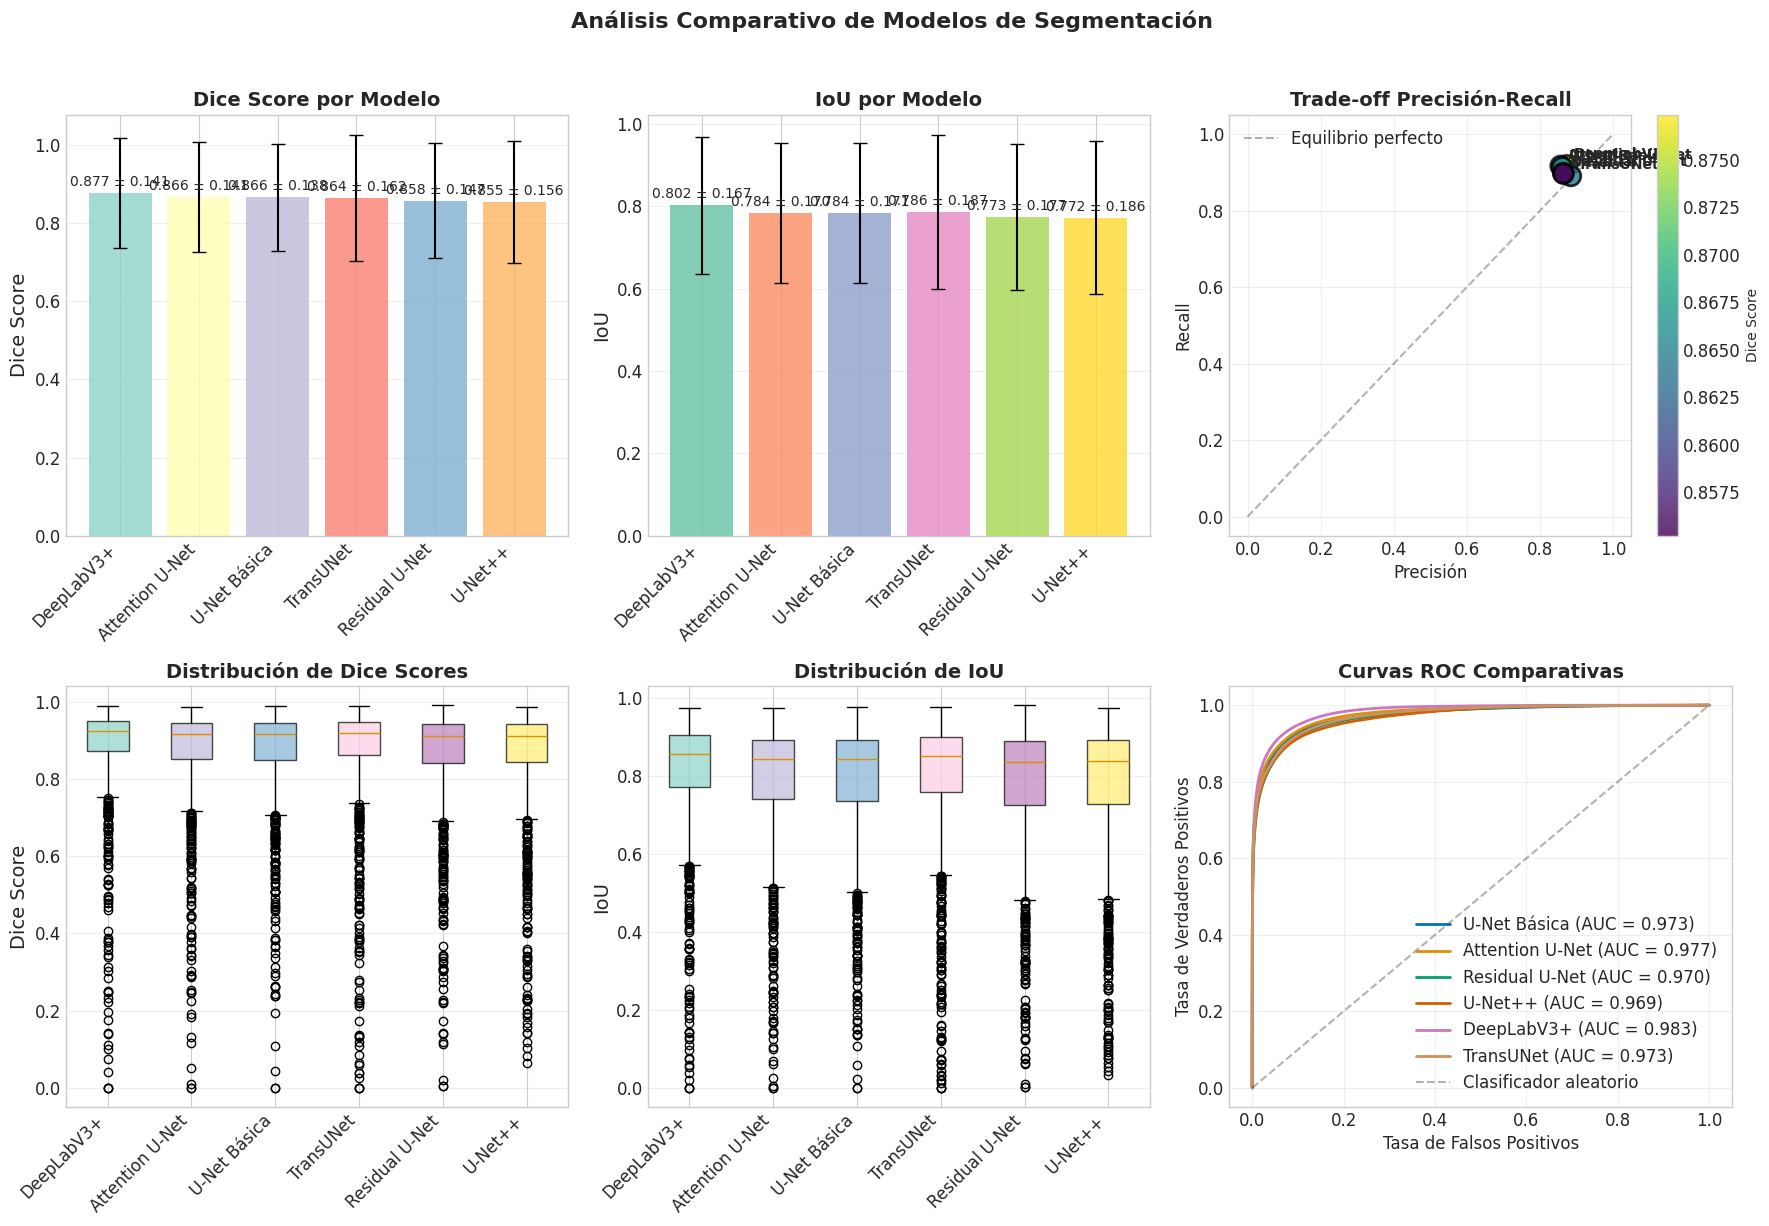

Figura 1 guardada: experiments/comparative_analysis/comparative_metrics_analysis.png


In [8]:
print("\nGENERANDO VISUALIZACIONES COMPARATIVAS")
print("="*50)

# Figura 1: Comparación de métricas principales
fig1, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1.1: Barras de Dice Score con intervalo de confianza
ax = axes[0, 0]
model_names = comparison_df['Modelo'].tolist()
dice_means = [evaluation_results[name]['aggregated_metrics']['dice_mean'] 
              for name in model_names]
dice_stds = [evaluation_results[name]['aggregated_metrics']['dice_std'] 
             for name in model_names]

bars = ax.bar(model_names, dice_means, yerr=dice_stds, capsize=5, 
              color=plt.cm.Set3(np.arange(len(model_names))), alpha=0.8)
ax.set_title('Dice Score por Modelo', fontsize=14, fontweight='bold')
ax.set_ylabel('Dice Score')
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Añadir valores
for bar, mean, std in zip(bars, dice_means, dice_stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
           f'{mean:.3f} ± {std:.3f}', ha='center', va='bottom', fontsize=10)

# 1.2: Barras de IoU
ax = axes[0, 1]
iou_means = [evaluation_results[name]['aggregated_metrics']['iou_mean'] 
             for name in model_names]
iou_stds = [evaluation_results[name]['aggregated_metrics']['iou_std'] 
            for name in model_names]

bars = ax.bar(model_names, iou_means, yerr=iou_stds, capsize=5,
              color=plt.cm.Set2(np.arange(len(model_names))), alpha=0.8)
ax.set_title('IoU por Modelo', fontsize=14, fontweight='bold')
ax.set_ylabel('IoU')
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for bar, mean, std in zip(bars, iou_means, iou_stds):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
           f'{mean:.3f} ± {std:.3f}', ha='center', va='bottom', fontsize=10)

# 1.3: Precisión vs Recall
ax = axes[0, 2]
precisions = comparison_df['Precisión'].astype(float).tolist()
recalls = comparison_df['Recall'].astype(float).tolist()

scatter = ax.scatter(precisions, recalls, s=200, 
                     c=comparison_df['Dice Score'].astype(float),
                     cmap='viridis', alpha=0.8, edgecolors='black', linewidth=2)

# Añadir etiquetas
for i, (name, prec, rec) in enumerate(zip(model_names, precisions, recalls)):
    ax.annotate(name, (prec, rec), xytext=(5, 5), textcoords='offset points',
               fontsize=10, fontweight='bold')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Equilibrio perfecto')
ax.set_xlabel('Precisión', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('Trade-off Precisión-Recall', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Barra de color para Dice Score
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Dice Score', fontsize=10)

# 1.4: Box plots de distribuciones de Dice
ax = axes[1, 0]
box_data = [evaluation_results[name]['sample_metrics']['dice'] 
            for name in model_names]
bp = ax.boxplot(box_data, labels=model_names, patch_artist=True)

# Colorear boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribución de Dice Scores', fontsize=14, fontweight='bold')
ax.set_ylabel('Dice Score')
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# 1.5: Box plots de distribuciones de IoU
ax = axes[1, 1]
box_data = [evaluation_results[name]['sample_metrics']['iou'] 
            for name in model_names]
bp = ax.boxplot(box_data, labels=model_names, patch_artist=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribución de IoU', fontsize=14, fontweight='bold')
ax.set_ylabel('IoU')
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# 1.6: Curvas ROC (si hay múltiples modelos)
ax = axes[1, 2]
if len(evaluation_results) > 1:
    for name, results in evaluation_results.items():
        # Concatenar todas las predicciones y targets
        all_probs = np.concatenate(results['probabilities'])
        all_targets = np.concatenate(results['targets'])
        
        # Calcular curva ROC
        fpr, tpr, _ = roc_curve(all_targets.flatten(), all_probs.flatten())
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Clasificador aleatorio')
    ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
    ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
    ax.set_title('Curvas ROC Comparativas', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Se requieren múltiples modelos\npara curvas ROC comparativas',
           ha='center', va='center', fontsize=12, transform=ax.transAxes)
    ax.set_title('Curvas ROC (requiere >1 modelo)', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Análisis Comparativo de Modelos de Segmentación', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Guardar figura
fig1_path = output_dir / 'comparative_metrics_analysis.png'
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figura 1 guardada: {fig1_path}")

## 7. Análisis de casos cualitativos

In [9]:
def visualize_qualitative_comparison(models_dict, data_loader, device, 
                                    num_cases=3, threshold=0.5):
    """
    Visualización comparativa cualitativa de múltiples modelos
    """
    """# Obtener batch de muestras
    batch = next(iter(data_loader))
    batch_size = batch['image'].size(0)
    num_cases = min(num_cases, batch_size)
    
    # Seleccionar casos interesantes (alta, media, baja dificultad)
    images = batch['image'].to(device)[:num_cases]
    true_masks = batch['mask'].to(device)[:num_cases]
    image_ids = batch['image_id'][:num_cases]"""
    
    
    dataset = data_loader.dataset
    total_samples = len(dataset)
    num_cases = min(num_cases, total_samples)
    random_indices = random.sample(range(total_samples), num_cases)
    samples = [dataset[i] for i in random_indices]

    images = torch.stack([s['image'] for s in samples]).to(device)
    true_masks = torch.stack([s['mask'] for s in samples]).to(device)
    image_ids = [s['image_id'] for s in samples]
    
    
    # Preparar figura
    n_models = len(models_dict)
    fig, axes = plt.subplots(num_cases, n_models + 2, 
                            figsize=(4*(n_models+2), 4*num_cases))
    
    if num_cases == 1:
        axes = axes.reshape(1, -1)
    
    for case_idx in range(num_cases):
        # Imagen original (desnormalizada)
        img_np = images[case_idx].cpu().numpy()
        img_np = np.transpose(img_np, (1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)
        
        # Ground truth
        true_mask = true_masks[case_idx, 0].cpu().numpy()
        coverage = true_mask.mean()
        
        # Mostrar imagen original
        axes[case_idx, 0].imshow(img_np)
        axes[case_idx, 0].set_title(f"Imagen\n{image_ids[case_idx][:10]}...", 
                                   fontsize=10)
        axes[case_idx, 0].axis('off')
        
        # Mostrar ground truth
        axes[case_idx, 1].imshow(true_mask, cmap='gray')
        axes[case_idx, 1].set_title(f"Ground Truth\nCov: {coverage:.1%}", 
                                   fontsize=10)
        axes[case_idx, 1].axis('off')
        
        # Predicciones de cada modelo
        for model_idx, (model_name, model_data) in enumerate(models_dict.items(), start=2):
            model = model_data['model']
            model.eval()
            
            with torch.no_grad():
                output = model(images[case_idx:case_idx+1])
                pred_prob = torch.sigmoid(output)[0, 0].cpu().numpy()
                pred_binary = (pred_prob > threshold).astype(np.float32)
            
            # Calcular métricas para este caso
            dice = 2 * (pred_binary * true_mask).sum() / (
                pred_binary.sum() + true_mask.sum() + 1e-6
            )
            
            # Mostrar predicción binaria con superposición
            overlay = img_np.copy()
            # Resaltar predicción en verde (TP/FP) y verdadero no detectado en rojo (FN)
            overlay[pred_binary == 1, 1] = 1.0  # Verde para predicción
            overlay[(true_mask == 1) & (pred_binary == 0), 0] = 1.0  # Rojo para FN
            
            axes[case_idx, model_idx].imshow(overlay)
            
            # Color del título según desempeño
            title_color = 'green' if dice > 0.7 else 'orange' if dice > 0.5 else 'red'
            
            axes[case_idx, model_idx].set_title(
                f"{model_name}\nDice: {dice:.3f}", 
                fontsize=10,
                color=title_color,
                fontweight='bold'
            )
            axes[case_idx, model_idx].axis('off')
    
    plt.suptitle('Comparación Cualitativa de Segmentaciones', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    return fig

Generando visualizaciones cualitativas...


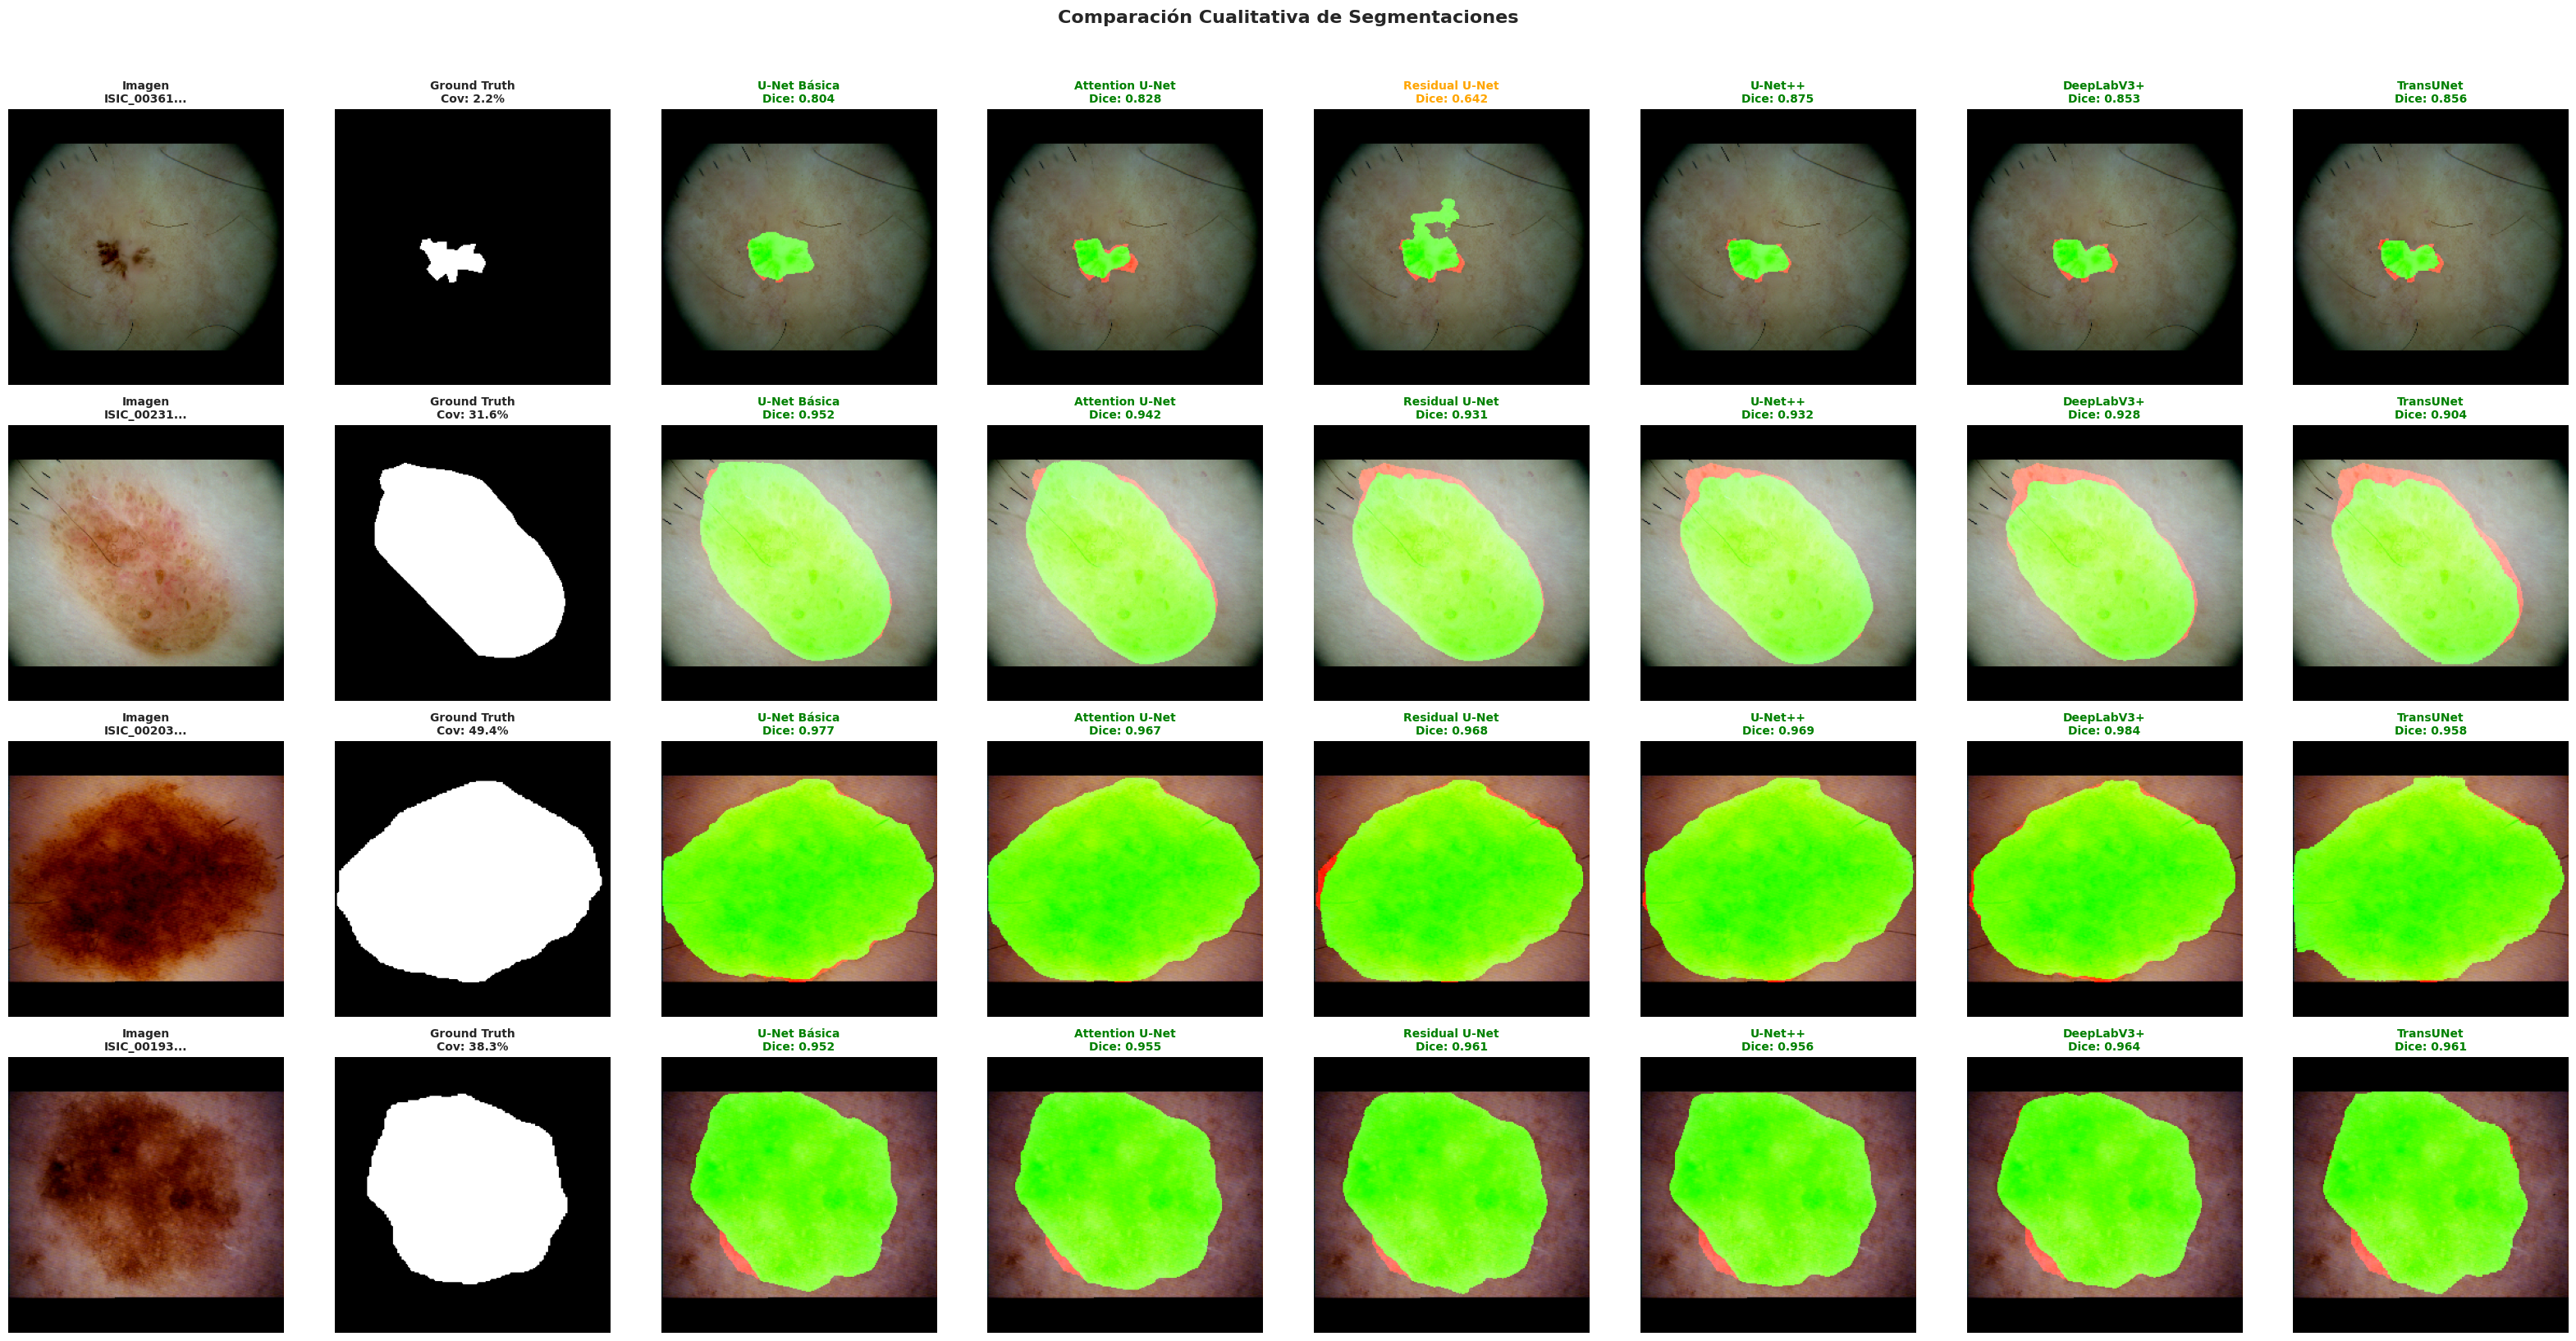

Figura cualitativa guardada: experiments/comparative_analysis/qualitative_comparison.png


In [16]:
# Preparar datos para visualización
models_for_viz = {name: {'model': data['model']} 
                  for name, data in trained_models.items()}

print("Generando visualizaciones cualitativas...")
qual_fig = visualize_qualitative_comparison(
    models_dict=models_for_viz,
    data_loader=eval_loader.test_loader,
    device=device,
    num_cases=min(4, EVAL_CONFIG['batch_size']),
    threshold=EVAL_CONFIG['threshold']
)

# Guardar figura
qual_path = output_dir / 'qualitative_comparison.png'
plt.savefig(qual_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figura cualitativa guardada: {qual_path}")


## 8. Análisis de eficiencia computacional


ANÁLISIS DE TIEMPO DE INFERENCIA POR MODELO
Total de imágenes en test set: 1000
Iteraciones de calentamiento: 5
--------------------------------------------------
U-Net Básica:
   Tiempo promedio: 5.01 ± 1.42 ms
   Rango: [3.74, 11.35] ms
   Tiempo total (1000 imgs): 5.01 s
   FPS: 199.4
   Tamaño: 118.4 MB (31.0M params)
Attention U-Net:
   Tiempo promedio: 6.25 ± 2.39 ms
   Rango: [4.14, 14.51] ms
   Tiempo total (1000 imgs): 6.25 s
   FPS: 160.0
   Tamaño: 119.7 MB (31.4M params)
Residual U-Net:
   Tiempo promedio: 6.42 ± 2.30 ms
   Rango: [4.10, 13.84] ms
   Tiempo total (1000 imgs): 6.42 s
   FPS: 155.7
   Tamaño: 123.7 MB (32.4M params)
U-Net++:
   Tiempo promedio: 6.92 ± 2.73 ms
   Rango: [3.83, 18.32] ms
   Tiempo total (1000 imgs): 6.92 s
   FPS: 144.5
   Tamaño: 34.5 MB (9.0M params)
DeepLabV3+:
   Tiempo promedio: 4.13 ± 2.06 ms
   Rango: [2.13, 12.04] ms
   Tiempo total (1000 imgs): 4.13 s
   FPS: 242.1
   Tamaño: 77.5 MB (20.3M params)
TransUNet:
   Tiempo promedio: 8.57 

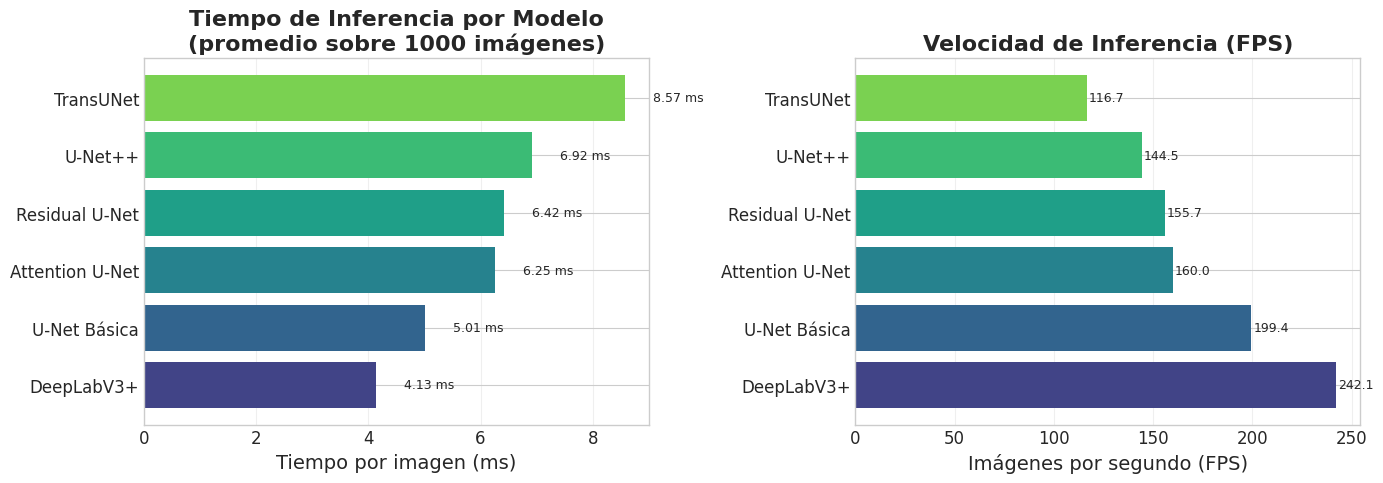


Gráfico guardado en: experiments/comparative_analysis/inference_time_comparison.png


In [14]:
import time

print("\nANÁLISIS DE TIEMPO DE INFERENCIA POR MODELO")
print("="*50)

# Calentamiento inicial
NUM_WARMUP = 5

inference_times = {}
test_dataset = eval_loader.test_loader.dataset
num_images = len(test_dataset)

print(f"Total de imágenes en test set: {num_images}")
print(f"Iteraciones de calentamiento: {NUM_WARMUP}")
print("-" * 50)

for name, model_data in trained_models.items():
    model = model_data['model']
    model.eval()
    
    # Calentamiento con primera imagen
    first_image = test_dataset[0]['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        for _ in range(NUM_WARMUP):
            _ = model(first_image)
            if device.type == 'cuda':
                torch.cuda.synchronize()
    
    # Medir tiempo de inferencia para cada imagen del test set
    times = []
    with torch.no_grad():
        for idx in range(num_images):
            # Cargar imagen individual
            sample = test_dataset[idx]
            single_image = sample['image'].unsqueeze(0).to(device)  # Shape: [1, 3, H, W]
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            start_time = time.perf_counter()
            
            _ = model(single_image)
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end_time = time.perf_counter()
            
            times.append(end_time - start_time)
    
    # Calcular estadísticas
    avg_time_ms = np.mean(times) * 1000  # ms
    std_time_ms = np.std(times) * 1000   # ms
    min_time_ms = np.min(times) * 1000   # ms
    max_time_ms = np.max(times) * 1000   # ms
    total_time_s = np.sum(times)         # segundos totales
    
    # Calcular tamaño del modelo en MB (asumiendo float32 = 4 bytes por parámetro)
    num_params = trained_models[name]['metadata']['params']
    model_size_mb = (num_params * 4) / (1024 * 1024)  # 4 bytes por parámetro float32
    
    inference_times[name] = {
        'avg_ms': avg_time_ms,
        'std_ms': std_time_ms,
        'min_ms': min_time_ms,
        'max_ms': max_time_ms,
        'total_s': total_time_s,
        'fps': 1000 / avg_time_ms,
        'num_images': num_images,
        'params': num_params,
        'size_mb': model_size_mb
    }
    
    print(f"{name}:")
    print(f"   Tiempo promedio: {avg_time_ms:.2f} ± {std_time_ms:.2f} ms")
    print(f"   Rango: [{min_time_ms:.2f}, {max_time_ms:.2f}] ms")
    print(f"   Tiempo total ({num_images} imgs): {total_time_s:.2f} s")
    print(f"   FPS: {1000/avg_time_ms:.1f}")
    print(f"   Tamaño: {model_size_mb:.1f} MB ({num_params/1e6:.1f}M params)")

# Crear DataFrame resumen
print("\n" + "="*50)
print(f"RESUMEN DE TIEMPOS DE INFERENCIA ({num_images} imágenes)")
print("="*50)

inference_df = pd.DataFrame([
    {
        'Modelo': name,
        'Tiempo/img (ms)': f"{t['avg_ms']:.2f} ± {t['std_ms']:.2f}",
        'Min (ms)': f"{t['min_ms']:.2f}",
        'Max (ms)': f"{t['max_ms']:.2f}",
        'Total (s)': f"{t['total_s']:.2f}",
        'FPS': f"{t['fps']:.1f}",
        'Parámetros (M)': f"{t['params'] / 1e6:.1f}",
        'Tamaño (MB)': f"{t['size_mb']:.1f}"
    }
    for name, t in inference_times.items()
])

# Ordenar por tiempo de inferencia
inference_df_sorted = inference_df.copy()
inference_df_sorted['_sort'] = [inference_times[name]['avg_ms'] for name in inference_df['Modelo']]
inference_df_sorted = inference_df_sorted.sort_values('_sort').drop('_sort', axis=1)

print(inference_df_sorted.to_string(index=False))

# Visualización de tiempos de inferencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ordenar modelos por tiempo de inferencia
sorted_models = sorted(inference_times.keys(), key=lambda x: inference_times[x]['avg_ms'])
sorted_times = [inference_times[m]['avg_ms'] for m in sorted_models]
sorted_fps = [inference_times[m]['fps'] for m in sorted_models]

# Gráfico de barras - Tiempo por imagen
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_models)))
bars = axes[0].barh(sorted_models, sorted_times, color=colors)
axes[0].set_xlabel('Tiempo por imagen (ms)')
axes[0].set_title(f'Tiempo de Inferencia por Modelo\n(promedio sobre {num_images} imágenes)')
axes[0].grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for bar, time_val in zip(bars, sorted_times):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{time_val:.2f} ms', va='center', fontsize=9)

# Gráfico de barras - FPS
bars2 = axes[1].barh(sorted_models, sorted_fps, color=colors)
axes[1].set_xlabel('Imágenes por segundo (FPS)')
axes[1].set_title('Velocidad de Inferencia (FPS)')
axes[1].grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for bar, fps_val in zip(bars2, sorted_fps):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{fps_val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / 'inference_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico guardado en: {output_dir / 'inference_time_comparison.png'}")

## 9. Guardar resultados completos del análisis

In [10]:
print("\nGUARDANDO RESULTADOS COMPLETOS DEL ANÁLISIS")
print("="*50)

best_model_name = comparison_df.iloc[0]['Modelo']
best_model_metrics = evaluation_results[best_model_name]['aggregated_metrics']

# Crear archivo de resumen
analysis_summary = {
    'configuracion_evaluacion': EVAL_CONFIG,
    'modelos_evaluados': list(trained_models.keys()),
    'mejor_modelo': {
        'nombre': best_model_name,
        'metricas': best_model_metrics
    },
    'resumen_estadistico': {
        'num_modelos': len(trained_models),
        'num_muestras': evaluation_results[best_model_name]['aggregated_metrics']['num_samples'],
        'dice_promedio': comparison_df['Dice Score'].mean(),
        'dice_maximo': comparison_df['Dice Score'].max(),
        'dice_minimo': comparison_df['Dice Score'].min()
    },
    'archivos_generados': [
        str(output_dir / 'metrics_comparison.csv'),
        str(output_dir / 'comparative_metrics_analysis.png'),
        str(output_dir / 'qualitative_comparison.png'),
        str(output_dir / 'comparison_state_of_art.png')
    ],
    'timestamp': pd.Timestamp.now().isoformat()
}

# Guardar como JSON
summary_path = output_dir / 'analysis_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(analysis_summary, f, indent=2, ensure_ascii=False, default=str)

print(f"Resumen del análisis guardado en: {summary_path}")

# Mostrar rutas de todos los archivos generados
print("\nARCHIVOS GENERADOS EN EL ANÁLISIS:")
for file_path in output_dir.rglob('*'):
    if file_path.is_file():
        file_size = file_path.stat().st_size / 1024  # Tamaño en KB
        print(f"   • {file_path.relative_to(output_dir)} ({file_size:.1f} KB)")


GUARDANDO RESULTADOS COMPLETOS DEL ANÁLISIS
Resumen del análisis guardado en: experiments/comparative_analysis/analysis_summary.json

ARCHIVOS GENERADOS EN EL ANÁLISIS:
   • metrics_comparison.csv (1.1 KB)
   • analysis_summary.json (1.8 KB)
   • false_positives_Attention U-Net.png (384.7 KB)
   • comparative_metrics_analysis.png (1100.9 KB)
   • qualitative_comparison.png (1531.4 KB)
